# Wilson-Cowan Third-Order Additive (TA) Model

**Model:** Third-order additive coupling architecture for Wilson-Cowan neural network

## Overview

This notebook implements and analyzes the Third-Order Additive (TA) coupling architecture in the Wilson-Cowan neural network model. It performs parameter sweeps over coupling strength P and K values to detect oscillatory behavior, computes transfer entropy (TE) and directed transfer entropy (DTE) as temporal causality measures, and generates cumulant maps (TC-DTC) to characterize higher-order statistical structure.

## Key Sections

- **Parameter sweep in (P,K) space:** Systematic exploration of oscillation detection across coupling parameters
- **Transfer entropy and directed transfer entropy computation:** Temporal causality analysis
- **Cumulant map generation:** Higher-order statistical structure quantification

---


In [1]:
import sys
import os
sys.path.append('../')  # Ensure Python can find the 'Scripts' folder

#from Scripts.parameters import *
#from Scripts.parameters_random import *
from Scripts.parameters import *
from Scripts.dynamics import *
from Scripts.simulation import *
from Scripts.oscillation_detection import *
from Scripts.metrics import *
from Scripts.visualization import *

print("Functions loaded successfully.")

# Parameter ranges for oscillation detection
P_values = np.linspace(1.0, 10.0, 20)
K_values = np.linspace(0.0, 1.0, 20)
K3_values = np.linspace(0.0, 1.0, 20)

Stable Rank  (M): 1.50
Nuclear Rank (M): 2.00
Effective Rank (95% energy, M): 3
Functions loaded successfully.


---
## **3. Basic Simulation with Higher-Order Interactions and Signal Plotting**
We simulate the model with higher-order interactions and visualize the signals.


Total timesteps: 18000
Analysis timesteps: 17001

Node 0:
  E: mean=0.2526, std=0.0849, range=[0.1356, 0.4128]
  I: mean=0.4624, std=0.0428, range=[0.3976, 0.5366]

Node 1:
  E: mean=0.1749, std=0.0670, range=[0.0806, 0.3273]
  I: mean=0.4417, std=0.0409, range=[0.3741, 0.5258]

Node 2:
  E: mean=0.1730, std=0.0594, range=[0.0864, 0.3053]
  I: mean=0.4372, std=0.0368, range=[0.3763, 0.5124]


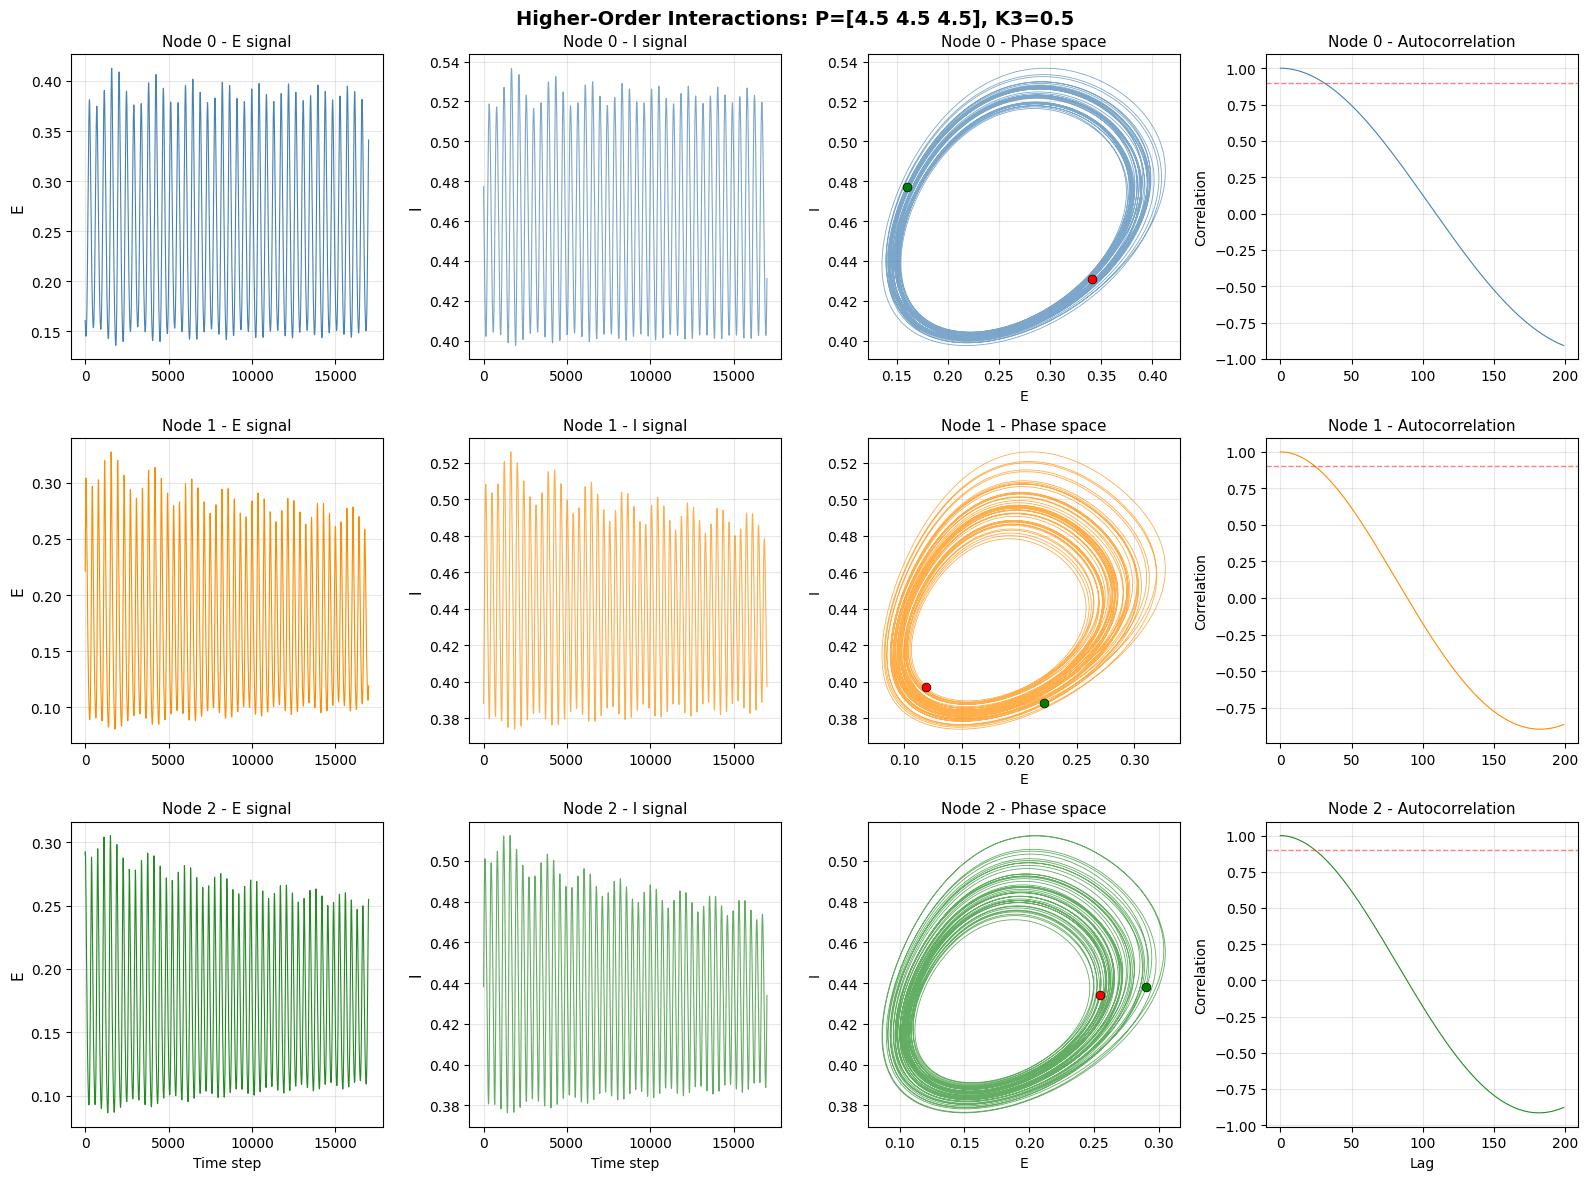

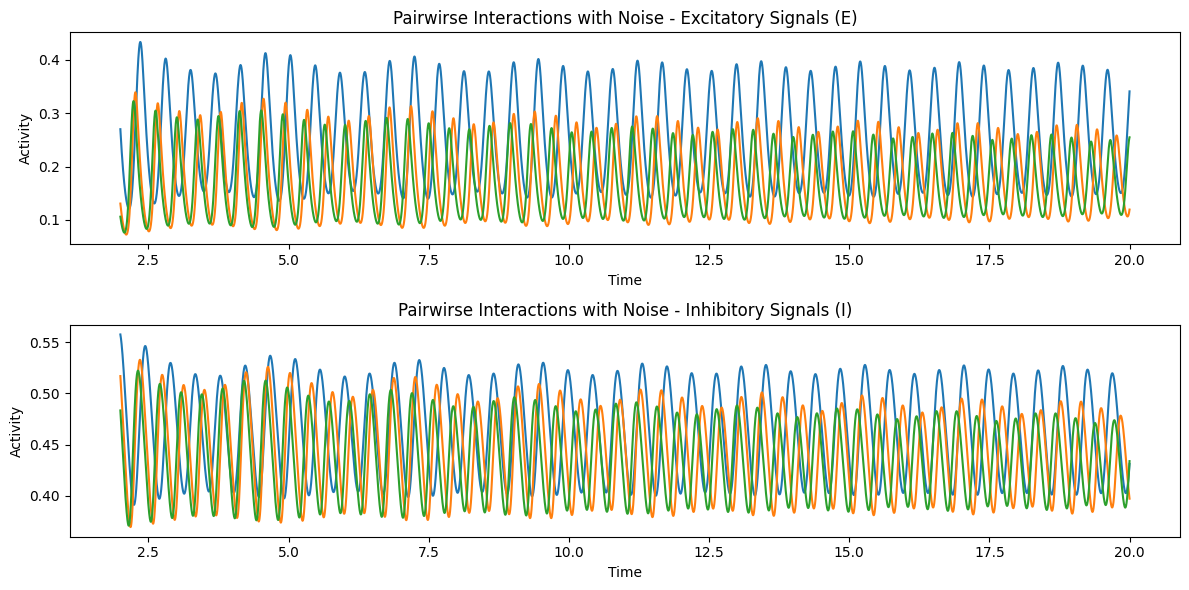

In [27]:
# Simulation parameters
P_sim = np.array([4.5, 4.5, 4.5])  # P per node
K3_sim = 0.5

#initial state
seed = 42
rng = np.random.default_rng(seed)
state0 = 0.1 * rng.standard_normal(2 * N_nodes)
T=20

# Simulation using the existing function for higher-order interactions
t, states = simulate_wc_higher_order(state0, P_sim, K3_sim, T_ho, T, dt)

# Remove transient
transient_time = 2.0
start_idx = min(int(transient_time / dt), len(t)-1)

# Extract signals
E = states[start_idx:, :N_nodes]
I = states[start_idx:, N_nodes:]

# Visualization using the existing function
plot_detailed_signals(t[start_idx:], states[start_idx:, :], N_nodes, P_sim=P_sim, K3_sim=K3_sim, title="Higher-Order Interactions")
plot_signals(t[start_idx:], E, I, title="Pairwirse Interactions with Noise")


### Results Visualization

Generate interactive plots and visualizations of the parameter sweep results.


---
## **4. Oscillation Detection in $(P \times K_3)$ Space**
We perform a parameter sweep to detect oscillations in the $(P \times K_3)$ space.


In [28]:
P_values = np.linspace(0.0, 10, 20)
K3_values = np.linspace(0.0, 1.0, 20)

# Matrix to store oscillation detection
oscillation_map = np.zeros((len(P_values), len(K3_values)), dtype=int)

T=20
# Matrices to store metrics with noise
TC_map = np.zeros((len(P_values), len(K3_values)))
DTC_map = np.zeros((len(P_values), len(K3_values)))
Cumulant_map = np.zeros((len(P_values), len(K3_values)))
PowerCorr_map = np.zeros((len(P_values), len(K3_values)))
Entropy_map = np.zeros((len(P_values), len(K3_values)))  # Nueva métrica
Entropy_map_skew = np.zeros((len(P_values), len(K3_values)))  # Nueva métrica
Entropy_map_kurt = np.zeros((len(P_values), len(K3_values)))  # Nueva métrica

#initial state random fixed
seed = 42
rng = np.random.default_rng(seed)
state0 = 0.1 * rng.standard_normal(2 * N_nodes)


for i, P_val in enumerate(P_values):
    for j, K3_val in enumerate(K3_values):
        # Simulation using the existing function for higher-order interactions
        P_vec = np.array([P_val, P_val, P_val])
        t, states = simulate_wc_higher_order(state0, P_vec, K3_val, T_ho, T, dt)

        #deleting the firts 20% of the signal
        start_idx = int(0.2 * len(t))

        E_node = states[start_idx:, :N_nodes]
        I_node = states[start_idx:, N_nodes:]

        # Oscillation detection using the existing function
        is_lc1, _, _, _ = detect_limit_cycle_poincare(E_node[:, 0], I_node[:, 0], dt, threshold_ratio=0.05, period_cv_threshold=0.05)
        is_lc2, _, _, _ = detect_limit_cycle_poincare(E_node[:, 0], I_node[:, 0], dt, threshold_ratio=0.05, period_cv_threshold=0.05)
        is_lc3, _, _, _ = detect_limit_cycle_poincare(E_node[:, 0], I_node[:, 0], dt, threshold_ratio=0.05, period_cv_threshold=0.05)
        oscillation_map[i, j]  = int((is_lc1==True) and (is_lc2==True) and (is_lc3==True))

        #deleting the firts 30% of the signal
        E = states[start_idx:, :N_nodes]

        # Data matrix for higher-order metrics
        X = E.copy()

        # Covariance matrix
        Sigma = np.cov(X.T)

        # Higher-order metrics using the existing functions
        TC_map[i, j] = TC_gauss(Sigma)
        DTC_map[i, j] = DTC_gauss(Sigma)
        Entropy_map[i, j] = entropy_gauss(Sigma)  # Cálculo de la entropía
        skew, kurt = dev_gauss(X)  # Cálculo de la entropía
        Entropy_map_skew[i, j] = skew
        Entropy_map_kurt[i, j] = kurt
        if X.shape[1] == 3:
            Cumulant_map[i, j] = cumulants(X)
            PowerCorr_map[i, j] = powercorr(X)


    if (i + 1) % 5 == 0:
        print(f"Progress: {i+1}/{len(P_values)}")

# Visualization using the existing function
#plot_oscillation_map(oscillation_map, P_values, K3_values, title="Oscillation Detection (P-K3)")


#cleaing the matrix
TC_clean = clean_rowwise_signed(TC_map, n_std=2)
DTC_clean = clean_rowwise_signed(DTC_map, n_std=2)
Cumulant_clean = clean_rowwise_signed(Cumulant_map,n_std=2)
PowerCorr_clean = clean_rowwise_signed(PowerCorr_map,n_std=2)
Skew_clean = clean_rowwise_signed(Entropy_map_skew,n_std=2)
Kurt_clean = clean_rowwise_signed(Entropy_map_kurt,n_std=2)

# visualization the matrix cleaned
plot_metrics_contour(oscillation_map, P_values, K3_values, title="Oscilation detection")

plot_metrics_contour(TC_clean, P_values, K3_values, title="Total Correlation (TC) without Noise")
plot_metrics_contour(DTC_clean, P_values, K3_values, title="Dual Total Correlation (DTC) without Noise")
plot_metrics_contour(Cumulant_clean, P_values, K3_values, title="Third-Order Cumulant without Noise")
plot_metrics_contour(PowerCorr_clean, P_values, K3_values, title="Triple Power Correlation without Noise")
plot_metrics_contour(Skew_clean, P_values, K3_values, title="skew with Noise")
plot_metrics_contour(Kurt_clean, P_values, K3_values, title="Kurt with Noise")

Progress: 5/20
Progress: 10/20
Progress: 15/20
Progress: 20/20


---
## **6. Model with Stochastic Noise and Higher-Order Interactions**
We add stochastic noise to the excitatory population (E) using the Euler-Maruyama method with higher-order interactions.

To include biological noise, we extend the excitatory population dynamics using the **Euler-Maruyama method**:

$$
E_i(t + \Delta t) = E_i(t) + \frac{\Delta t}{\tau_E} \left(-E_i(t) + S\left(c_{EE} E_i - c_{IE} I_i + P + K_3 \sum_{j,k} T_{ijk} E_j E_k\right)\right) + \frac{\sigma_E \sqrt{\Delta t}}{\tau_E} \xi_i
$$

- $(\sigma_E)$: Noise intensity for the excitatory population.
- $(\xi_i \sim \mathcal{N}(0, 1))$: Gaussian white noise.

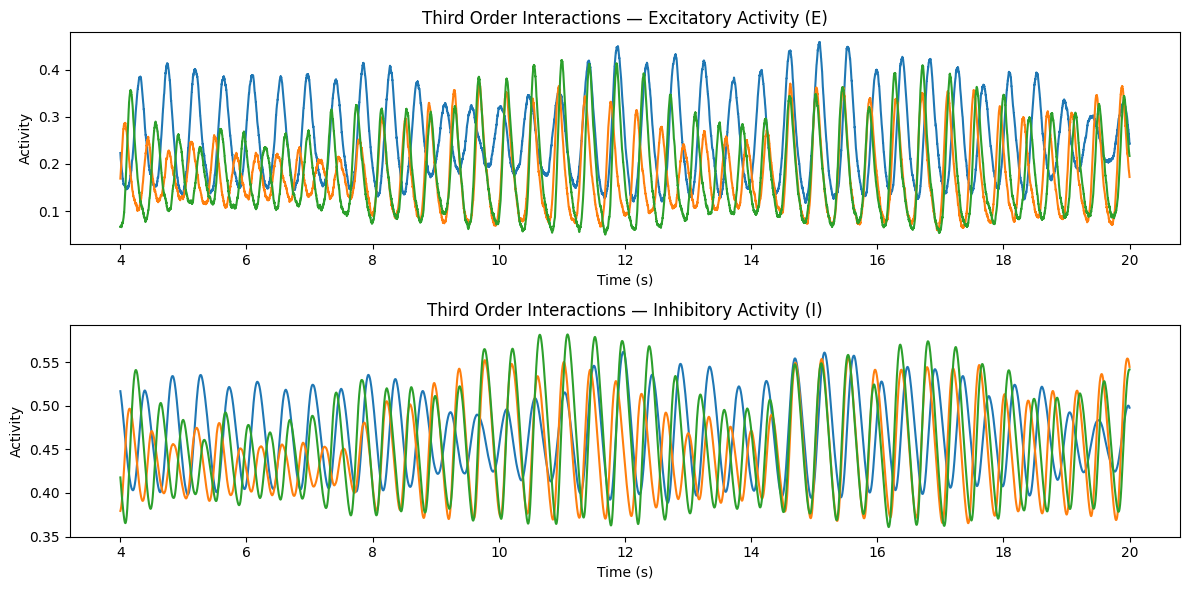

Total timesteps : 20000
Analysis timesteps: 19001

Node 0:
  E: mean=0.2567, std=0.0940, range=[0.0880, 0.5130]
  I: mean=0.4689, std=0.0492, range=[0.3786, 0.6088]

Node 1:
  E: mean=0.1808, std=0.0835, range=[0.0461, 0.5084]
  I: mean=0.4519, std=0.0557, range=[0.3584, 0.6392]

Node 2:
  E: mean=0.1844, std=0.0935, range=[0.0499, 0.4710]
  I: mean=0.4592, std=0.0614, range=[0.3596, 0.6281]


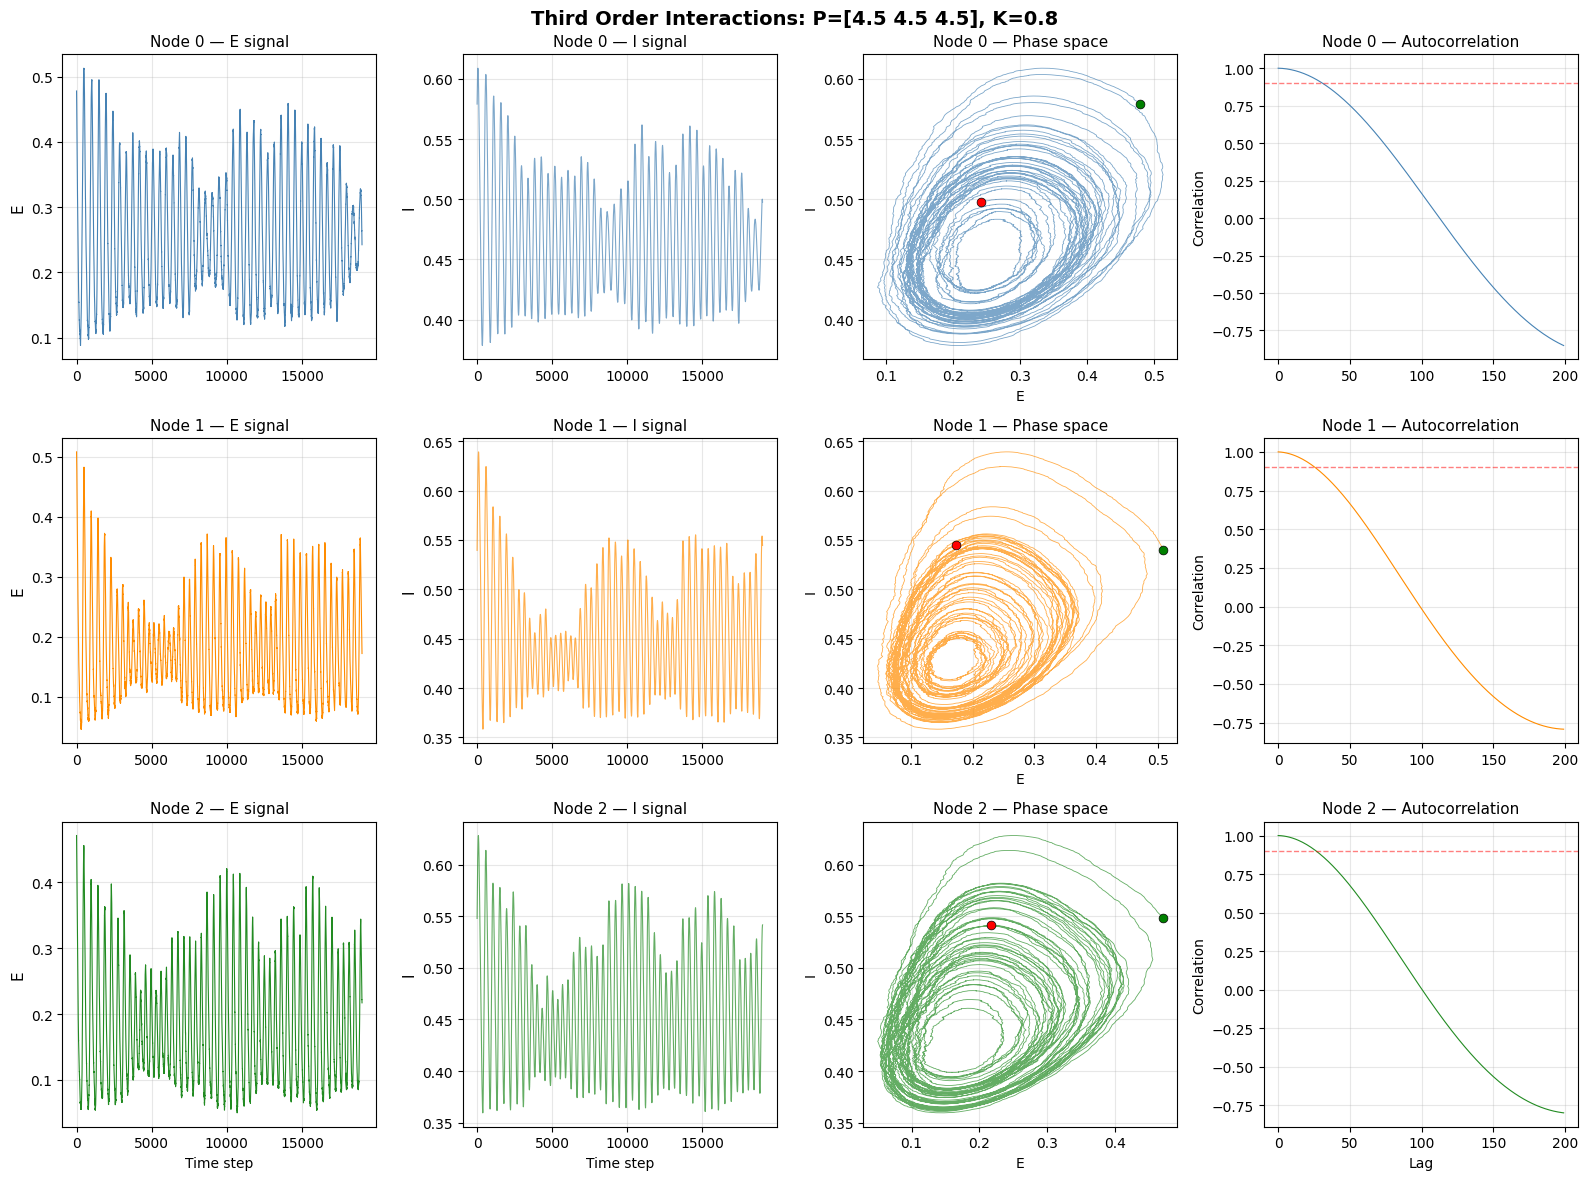

In [2]:
# Simulation parameters with noise
P_sim = np.array([4.5, 4.5, 4.5])  # P per node
#K_sim = 0.5
#P_sim = np.array([0, 0, 0])  # P per node
K_sim = 0.8


# Initial state
#initial state
seed = 42
rng = np.random.default_rng(seed)
state0 = 0.1 * rng.standard_normal(2 * N_nodes)
T=20
sigma_E = 0.03

# Simulation with noise using the existing function
t, states = simulate_wc_higher_order_stochastic(state0, P_sim, K_sim, T_ho, T, dt, sigma_E=0.03)

# Extract signals
start_idx = int(0.2 * len(t))
E = states[start_idx:, :N_nodes]
I = states[start_idx:, N_nodes:]
#E = states[:, :N_nodes]
#I = states[:, N_nodes:]

# Visualization using the existing function
plot_signals(t[start_idx:], E, I, title="Third Order Interactions")
# Visualization using the existing function
plot_detailed_signals(t, states, N_nodes, P_sim=P_sim, K_sim=K_sim, title="Third Order Interactions")



### Results Visualization

Generate interactive plots and visualizations of the parameter sweep results.


/var/folders/f5/3603lrxn363_ddpmt3c65sfm0000gn/T/ipykernel_2756/3972741896.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved → ../results/fig_oscillation.pdf


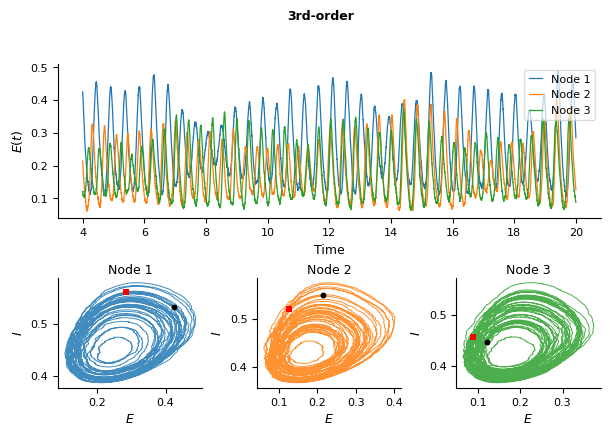

In [10]:
def plot_oscillation_summary(t, states, N_nodes,
                              transient_frac=0.2,
                              title="",
                              savepath=None,
                              node_colors=None):
    """
    Compact oscillation figure for a 2-column RevTeX paper.

    Layout:
        Row 1        : E(t) time series for all nodes (full width)
        Row 2 col 1  : Phase portrait node 0  (E vs I)
        Row 2 col 2  : Phase portrait node 1
        Row 2 col 3  : Phase portrait node 2

    Parameters
    ----------
    t            : ndarray (n_steps,)   time vector
    states       : ndarray (n_steps, 2*N_nodes)
    N_nodes      : int
    transient_frac : float  fraction of t to discard as transient (default 0.2)
    title        : str      suptitle (leave '' for no title)
    savepath     : str|None if given, save figure there (PDF recommended)
    node_colors  : list of 3 colours (default: blue, orange, green)
    """
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    # ── global font settings ──────────────────────────────────────────────
    mpl.rcParams.update({
        'font.size':        9,
        'axes.titlesize':   9,
        'axes.labelsize':   9,
        'xtick.labelsize':  8,
        'ytick.labelsize':  8,
        'legend.fontsize':  8,
        'lines.linewidth':  1.0,
    })

    if node_colors is None:
        node_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']   # mpl default cycle

    # ── trim transient ────────────────────────────────────────────────────
    start = int(transient_frac * len(t))
    t_plot  = t[start:]
    E = states[start:, :N_nodes]
    I = states[start:, N_nodes:]

    # ── figure geometry ───────────────────────────────────────────────────
    # single column ≈ 3.4 in  →  use full two-column width = 7.0 in
    FIG_W = 7.0
    FIG_H = 4.2          # two rows: signal (taller) + phase portraits

    fig = plt.figure(figsize=(FIG_W, FIG_H))

    gs = gridspec.GridSpec(
        2, 3,
        figure=fig,
        height_ratios=[1.4, 1.0],   # signal row slightly taller
        hspace=0.45,
        wspace=0.38,
    )

    # ── Row 1: time series (spans all 3 columns) ──────────────────────────
    ax_t = fig.add_subplot(gs[0, :])

    for n in range(N_nodes):
        ax_t.plot(t_plot, E[:, n],
                  color=node_colors[n],
                  linewidth=0.9,
                  label=f"Node {n+1}")

    ax_t.set_xlabel("Time", fontsize=9)
    ax_t.set_ylabel("$E(t)$",      fontsize=9)
    ax_t.tick_params(labelsize=8)
    ax_t.legend(loc="upper right", fontsize=8,
                framealpha=0.7, handlelength=1.2)
    ax_t.spines[['top', 'right']].set_visible(False)

    # ── Row 2: phase portraits ────────────────────────────────────────────
    for n in range(N_nodes):
        ax_p = fig.add_subplot(gs[1, n])

        ax_p.plot(E[:, n], I[:, n],
                  color=node_colors[n],
                  linewidth=0.7,
                  alpha=0.85)

        # mark start and end
        ax_p.scatter(E[0, n],  I[0, n],
                     color='black', s=18, zorder=5,
                     marker='o', linewidths=0.0)
        ax_p.scatter(E[-1, n], I[-1, n],
                     color='red',   s=18, zorder=5,
                     marker='s', linewidths=0.0)

        ax_p.set_xlabel("$E$", fontsize=9)
        ax_p.set_ylabel("$I$", fontsize=9)
        ax_p.set_title(f"Node {n+1}", fontsize=9, pad=3)
        ax_p.tick_params(labelsize=8)
        ax_p.spines[['top', 'right']].set_visible(False)

    if title:
        fig.suptitle(title, fontsize=9, fontweight='bold', y=1.01)

    fig.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
        print(f"Saved → {savepath}")

    plt.close(fig)
    return fig


plot_oscillation_summary(
    t[start_idx:], 
    states[start_idx:],
    N_nodes,
    transient_frac=0.0,          # ya cortaste el transitorio antes
    title="3rd-order",
    savepath="../results/fig_oscillation.pdf"
)

Figure saved to ../results/fig_oscillation.pdf


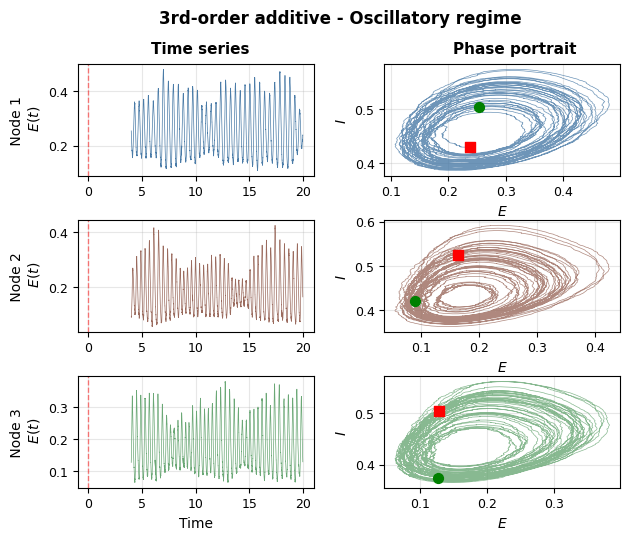

(<Figure size 700x550 with 6 Axes>, GridSpec(3, 2))

In [36]:
def plot_oscillation_summary(E_list, I_list, t, t_start=500, save_path=None, dpi=300):
    """
    Plot oscillation summary with 3 rows × 2 columns layout:
    - Left column: E(t) time series for each node
    - Right column: Phase portraits (E vs I) for each node

    Parameters:
    -----------
    E_list : list of arrays
        Excitatory activity for each node
    I_list : list of arrays
        Inhibitory activity for each node
    t : array
        Time vector
    t_start : int
        Time point to start plotting (for transient removal)
    save_path : str, optional
        Path to save the figure
    dpi : int
        Resolution for saved figure
    """
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    import numpy as np

    # Define colors for each node
    colors = ['#4A7BA7', '#9B6B5E', '#6BA876']

    # Font settings
    font_base = 10
    font_title = 11
    font_label = 10
    font_tick = 9
    font_legend = 9

    # Create figure with custom layout
    fig = plt.figure(figsize=(7.0, 5.5), dpi=100)
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)

    # Find index where t >= t_start
    idx_start = np.where(t >= t_start)[0][0]
    t_trim = t[idx_start:]

    # Create plots for each node
    for node_idx in range(3):
        E_trim = E_list[node_idx][idx_start:]
        I_trim = I_list[node_idx][idx_start:]

        # LEFT COLUMN: E(t) vs time
        ax_time = fig.add_subplot(gs[node_idx, 0])
        ax_time.plot(t_trim, E_trim, color=colors[node_idx], linewidth=0.5, label=f'Node {node_idx+1}')
        ax_time.axvline(x=t_start, color='red', linestyle='--', alpha=0.5, linewidth=1)
        ax_time.set_ylabel(f' Node {node_idx+1} \n $E(t)$', fontsize=font_label)
        if node_idx == 2:
            ax_time.set_xlabel('Time', fontsize=font_label)
        ax_time.tick_params(labelsize=font_tick)
        #ax_time.set_title(f'Node {node_idx+1}: Time Series', fontsize=font_title)
        ax_time.grid(True, alpha=0.3)

        # RIGHT COLUMN: Phase portrait (E vs I)
        ax_phase = fig.add_subplot(gs[node_idx, 1])
        ax_phase.plot(E_trim, I_trim, color=colors[node_idx], linewidth=0.5, alpha=0.8)
        ax_phase.scatter(E_trim[0], I_trim[0], color='green', s=50, marker='o',
                        label='Start', zorder=5)
        ax_phase.scatter(E_trim[-1], I_trim[-1], color='red', s=50, marker='s',
                        label='End', zorder=5)
        ax_phase.set_xlabel('$E$', fontsize=font_label)
        ax_phase.set_ylabel('$I$', fontsize=font_label)
        ax_phase.tick_params(labelsize=font_tick)
        #ax_phase.set_title(f'Node {node_idx+1}: Phase Portrait', fontsize=font_title)
        ax_phase.grid(True, alpha=0.3)
        #if node_idx == 0:
            #ax_phase.legend(fontsize=font_legend, loc='best')

    # Add column titles
    fig.text(0.3, 0.9, 'Time series', ha='center', fontsize=font_title, fontweight='bold')
    fig.text(0.75, 0.9, 'Phase portrait', ha='center', fontsize=font_title, fontweight='bold')
    
    # Overall title
    fig.suptitle('3rd-order additive - Oscillatory regime', fontsize=font_title + 1, fontweight='bold')


    # Save if requested
    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved to {save_path}")

    plt.show()

    return fig, gs


# Convertir a listas de arrays (uno por nodo)
E_list = [E[:, i] for i in range(N_nodes)]
I_list = [I[:, i] for i in range(N_nodes)]

# Vector de tiempo (ajustado a start_idx)
t_plot = t[start_idx:]

# Llamar la función
plot_oscillation_summary(E_list, I_list, t_plot, t_start=0, save_path="../results/fig_oscillation.pdf")

---
## **7. Oscillation Detection in $(P \times K$) Space** with noise
We perform a parameter sweep to detect oscillations in the $(P \times K$) space.


In [4]:
P_values = np.linspace(0.0, 10, 20)
K_values = np.linspace(0.0, 1.0, 20)
K3_values = np.linspace(0.0, 1.0, 20)
sigma_E = 0.03
#T=150 # 2 minutes
T=375


# Matrices to store metrics with noise
TC_map_noise = np.zeros((len(P_values), len(K_values)))
DTC_map_noise = np.zeros((len(P_values), len(K_values)))
Cumulant_map_noise = np.zeros((len(P_values), len(K_values)))
PowerCorr_map_noise = np.zeros((len(P_values), len(K_values)))
Entropy_map_noise = np.zeros((len(P_values), len(K_values)))  # Nueva métrica
Entropy_map_skew = np.zeros((len(P_values), len(K3_values)))  # Nueva métrica
Entropy_map_kurt = np.zeros((len(P_values), len(K3_values)))  # Nueva métrica

TC_ksg_map = np.zeros((len(P_values), len(K3_values)))
DTC_ksg_map = np.zeros((len(P_values), len(K3_values)))
Oinfo_ksg_map = np.zeros((len(P_values), len(K3_values)))


# Matrix to store oscillation detection with noise
oscillation_map_noise = np.zeros((len(P_values), len(K3_values)), dtype=int)
# mean_map = np.zeros((len(P_values), len(K_values), N_nodes))

#initial state
seed = 42
rng = np.random.default_rng(seed)
state0 = 0.1 * rng.standard_normal(2 * N_nodes)

# Create folder for raw simulated signals
sim_folder = '../simulations/3rd_order_additive'
os.makedirs(sim_folder, exist_ok=True)

for i, P_val in enumerate(P_values):
    for j, K3_val in enumerate(K3_values):
        # Simulation with noise using the existing function for higher-order interactions
        # t, states = simulate_wc_stochastic(state0, P_val, K3_val, M, T, dt, sigma_E=sigma_E, higher_order=True, T_ho=T_ho)
        P_vec = np.array([P_val, P_val, P_val])
        #t, states = simulate_wc_stochastic(state0, P_vec, K3_val, M, T, dt, sigma_E = sigma_E, higher_order=True, T_ho=T_ho)
        t, states = simulate_wc_higher_order_stochastic(state0, P_vec, K3_val, T_ho, T, dt, sigma_E=0.01)
    
        start_idx = int(0.2 * len(t))
        E_node = states[start_idx:, :N_nodes]
        I_node = states[start_idx:, N_nodes:]

        # Oscillation detection using the existing function
        is_lc1, _, _, _ = detect_limit_cycle_poincare(E_node[:, 0], I_node[:, 0], dt, threshold_ratio=0.05, period_cv_threshold=0.05)
        is_lc2, _, _, _ = detect_limit_cycle_poincare(E_node[:, 0], I_node[:, 0], dt, threshold_ratio=0.05, period_cv_threshold=0.05)
        is_lc3, _, _, _ = detect_limit_cycle_poincare(E_node[:, 0], I_node[:, 0], dt, threshold_ratio=0.05, period_cv_threshold=0.05)
        oscillation_map_noise[i, j]  = int((is_lc1==True) and (is_lc2==True) and (is_lc3==True))

        # quitar transiente (ej. mitad inicial)
        # cut = int(0.5 * len(t))
        # E_ss = E_node[cut:, :]
        # mean firing per node
        # mean_map[i, j, :] = np.mean(E_ss, axis=0)


        # Remove transient
        E = states[start_idx:, :N_nodes]

        # Data matrix for higher-order metrics
        X = E.copy()

        # Covariance matrix
        Sigma = np.cov(X.T)

        # Higher-order metrics using the existing functions
        TC_map_noise[i, j] = TC_gauss(Sigma)
        DTC_map_noise[i, j] = DTC_gauss(Sigma)
        skew, kurt = dev_gauss(X)  # Cálculo de la entropía
        Entropy_map_skew[i, j] = skew
        Entropy_map_kurt[i, j] = kurt
        #Entropy_map_noise[i, j] = dev_gauss(Sigma)  # Cálculo de la entropía
        if X.shape[1] == 3:
            Cumulant_map_noise[i, j] = cumulants(X)
            PowerCorr_map_noise[i, j] = powercorr(X)

        # --- KSG non-parametric metrics ---
        if X.shape[1] == 3:
            TC_ksg_map[i, j] = TC_ksg(X)
            DTC_ksg_map[i, j] = DTC_ksg(X)
            Oinfo_ksg_map[i, j] = Oinfo_ksg(X)

        # --- Save raw simulated signals ---
        I_node_save = states[start_idx:, N_nodes:]
        #np.savez_compressed(sim_folder + '/signals_i' + str(i).zfill(2) + '_j' + str(j).zfill(2) + '.npz',E=E, I=I_node_save,row_val=P_val, col_val=K3_val)

    if (i + 1) % 5 == 0:
        print(f"Progress: {i+1}/{len(P_values)}")

# Visualization using the existing function
# plot_oscillation_map(oscillation_map_noise, P_values, K3_values, title="Oscillation Detection (P-K3) with Noise")

# Visualization using the existing functions

#cleaing the matrix
TC_clean = clean_rowwise_signed(TC_map_noise, n_std=2)
DTC_clean = clean_rowwise_signed(DTC_map_noise, n_std=2)
Cumulant_clean = clean_rowwise_signed(Cumulant_map_noise,n_std=2)
PowerCorr_clean = clean_rowwise_signed(PowerCorr_map_noise,n_std=2)
Skew_clean = clean_rowwise_signed(Entropy_map_skew,n_std=2)
Kurt_clean = clean_rowwise_signed(Entropy_map_kurt,n_std=2)

TC_ksg_clean = clean_rowwise_signed(TC_ksg_map, n_std=2)
DTC_ksg_clean = clean_rowwise_signed(DTC_ksg_map, n_std=2)
Oinfo_ksg_clean = clean_rowwise_signed(Oinfo_ksg_map, n_std=2)

# visualization the matrix cleaned
plot_metrics_contour(oscillation_map_noise, P_values, K3_values, title="Oscilation detection")

plot_metrics_contour(TC_clean, P_values, K3_values, title="Total Correlation (TC) witht Noise")
plot_metrics_contour(DTC_clean, P_values, K3_values, title="Dual Total Correlation (DTC) witht Noise")
plot_metrics_contour(Cumulant_clean, P_values, K3_values, title="Third-Order Cumulant witht Noise")
plot_metrics_contour(PowerCorr_clean, P_values, K3_values, title="Triple Power Correlation witht Noise")
plot_metrics_contour(Skew_clean, P_values, K3_values, title="skew with Noise")
plot_metrics_contour(Kurt_clean, P_values, K3_values, title="Kurt with Noise")

plot_metrics_contour(TC_ksg_clean, P_values, K3_values, title="TC KSG with Noise")
plot_metrics_contour(DTC_ksg_clean, P_values, K3_values, title="DTC KSG with Noise")
plot_metrics_contour(Oinfo_ksg_clean, P_values, K3_values, title="O-info KSG with Noise")


#os.makedirs("results", exist_ok=True)
np.savez_compressed(
    "../results/"
    ".npz",
    oscillation_map=oscillation_map_noise,
    TC=TC_clean,
    DTC=DTC_clean,
    cumulant=Cumulant_clean,
    powercorr=PowerCorr_clean,
    skew=Skew_clean,
    kurt=Kurt_clean,
    TC_ksg=TC_ksg_clean,
    DTC_ksg=DTC_ksg_clean,
    Oinfo_ksg=Oinfo_ksg_clean,
    P=P_values,
    K3=K3_values
)

np.savez_compressed(
    "../results/raw_metrics_Coupling_noise.npz",
    oscillation_map=oscillation_map_noise,
    TC=TC_map_noise,
    DTC=DTC_map_noise,
    cumulant=Cumulant_map_noise,
    powercorr=PowerCorr_map_noise,
    skew=Entropy_map_skew,
    kurt=Entropy_map_kurt,
    TC_ksg=TC_ksg_map,
    DTC_ksg=DTC_ksg_map,
    Oinfo_ksg=Oinfo_ksg_map,
    P=P_values,
    K3=K3_values
)

Progress: 5/20
Progress: 10/20
Progress: 15/20
Progress: 20/20


In [3]:
import os
#os.makedirs("results", exist_ok=True)
np.savez_compressed(
    "../results/metrics_Coupling_noise.npz",
    oscillation_map=oscillation_map_noise,
    TC=TC_clean,
    DTC=DTC_clean,
    cumulant=Cumulant_clean,
    powercorr=PowerCorr_clean,
    skew=Skew_clean,
    kurt=Kurt_clean,
    P=P_values,
    K3=K3_values
)

In [5]:
import plotly.graph_objects as go
import numpy as np

def plot_metrics_contour(matrix, P_values, K_values, title="Metric Map",
                         colorscale="Inferno", n_contours=15, horizontal_lines=False,P1=0,P2=0):

    z_min = np.nanmin(matrix)
    z_max = np.nanmax(matrix)

    fig = go.Figure(data=go.Contour(
        z=matrix,
        x=K_values,
        y=P_values,
        colorscale=colorscale,
        contours=dict(
            start=z_min,
            end=z_max,
            size=(z_max - z_min) / n_contours,
            coloring='heatmap',
            showlines=True
        ),
        colorbar=dict(
            thickness=12,
            len=0.8
        )
    ))

    if horizontal_lines:
        # líneas horizontales
        fig.add_hline(y=P1, line=dict(color="lightblue", width=3), line_dash="dash")
        fig.add_hline(y=P2, line=dict(color="lightblue", width=3), line_dash="dash")
    
    fig.update_layout(
        title=title,
        xaxis_title='K',
        yaxis_title='P',
        width=500,
        height=400,
        margin=dict(l=60, r=40, t=50, b=50)
    )

    fig.show()

metrics = ["oscillation_map","TC","DTC","cumulant","powercorr","skew","kurt"]
pairwise = np.load("../results/metrics_Coupling_noise.npz")
for m in metrics:
    plot_metrics_contour(pairwise[m], pairwise["P"], pairwise["K3"], title=f"{m} with Noise",horizontal_lines=True,P1=5,P2=9)

### Oscillation Detection in Parameter Space

Perform a parameter sweep to systematically detect oscillatory behavior across the (P, K) parameter space. For each parameter combination, simulate the system and analyze the output for oscillations.
